# **DS3040 Introduction to Deep Learning**

## **1. Develop a next-word predictor using different recurrent neural network architectures**

### a) Load the shakespeare-hamlet.txt from the Gutenberg corpus of NLTK and perform necessary preprocessing
### b) Tokenize the text, create word sequences, apply padding, and generate input sequence next word pairs for training.
### c) Construct and train a language model using RNN and LSTM architectures
### d) Describe the effectiveness of each model (RNN, LSTM) in performing the next word prediction task, comparing their performance

In [82]:
import re
import string
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from torch.utils.data import DataLoader, Dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from nltk.corpus import stopwords

In [62]:
def preprocess_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('','', string.punctuation))
    words = [w for w in text.split() if w not in stop_words]
    return words

In [63]:
def train_and_evaluate(model,train_loader, criterion, optimizer, epochs = 5):
    model.train()
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs=model(inputs)
            if outputs.shape!=targets.shape and len(targets.shape)==1:
                outputs = outputs.squeeze()
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
        avg_loss=total_loss/len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    return loss_history

In [64]:
def plot_losses(losses_dict, title):
    plt.figure(figsize=(10,6))
    for model_name, losses in losses_dict.items():
        plt.plot(losses, label=model_name, marker='o')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [65]:
with open ('/home/142301026/Downloads/Deep_Learning/Lab5/data/shakespeare-hamlet.txt', 'r') as f:
    content = f.read()

In [66]:
"""
with open ('/home/142301026/Downloads/Deep_Learning/Lab5/nltk_data/nltk_data/corpora/stopwords/english') as f:
    stopwords = f.read()
"""
stop_words = set(stopwords.words('english'))
hamlet_text = content
hamlet_tokens = preprocess_text(hamlet_text)

In [67]:
hamlet_vocab = {word: i for i, (word,count) in enumerate(Counter(hamlet_tokens).items())}
vocab_size_lm = len(hamlet_vocab)
hamlet_seq = [hamlet_vocab[word] for word in hamlet_tokens]

In [68]:
seq_length = 50
inputs_lm, targets_lm = [],[]

In [69]:
for i in range(len(hamlet_seq)-seq_length):
    inputs_lm.append(hamlet_seq[i:i+seq_length])
    targets_lm.append(hamlet_seq[i+seq_length])

In [70]:
X_lm = torch.tensor(inputs_lm, dtype = torch.long)
y_lm = torch.tensor(targets_lm, dtype = torch.long)

lm_dataset = torch.utils.data.TensorDataset(X_lm, y_lm)
lm_loader = DataLoader(lm_dataset, batch_size = 128, shuffle = True)

In [71]:
class NextWordModel(nn.Module):
    def __init__(self, rnn_type, vocab_size, embed_dim, hidden_dim):
        super(NextWordModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        if rnn_type == 'RNN':
            self.rnn =  nn.RNN(embed_dim, hidden_dim, batch_first = True)
        if rnn_type == 'LSTM':
            self.rnn =  nn.LSTM(embed_dim, hidden_dim, batch_first = True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self,x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)

        if isinstance(hidden, tuple):
            hidden = hidden[0]

        final_hidden = hidden[-1]
        return self.fc(final_hidden)

In [72]:
lm_embed_dim = 64
lm_hidden_dim = 128
criterion_lm = nn.CrossEntropyLoss()

In [73]:
models_lm = {
    'RNN': NextWordModel('RNN', vocab_size_lm, lm_embed_dim, lm_hidden_dim),
    'LSTM': NextWordModel('LSTM', vocab_size_lm, lm_embed_dim, lm_hidden_dim)
}

lm_loss_results = {}

In [74]:
for name, model in models_lm.items():
    print(f"Training {name} for Next Word Prediction")
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    lm_loss_results[name] = train_and_evaluate(model,lm_loader,criterion_lm, optimizer, epochs=5)

Training RNN for Next Word Prediction
Epoch 1/5, Loss: 7.9543
Epoch 2/5, Loss: 6.6780
Epoch 3/5, Loss: 5.1129
Epoch 4/5, Loss: 3.5713
Epoch 5/5, Loss: 2.5266
Training LSTM for Next Word Prediction
Epoch 1/5, Loss: 7.8403
Epoch 2/5, Loss: 7.0071
Epoch 3/5, Loss: 5.7041
Epoch 4/5, Loss: 4.0644
Epoch 5/5, Loss: 2.7368


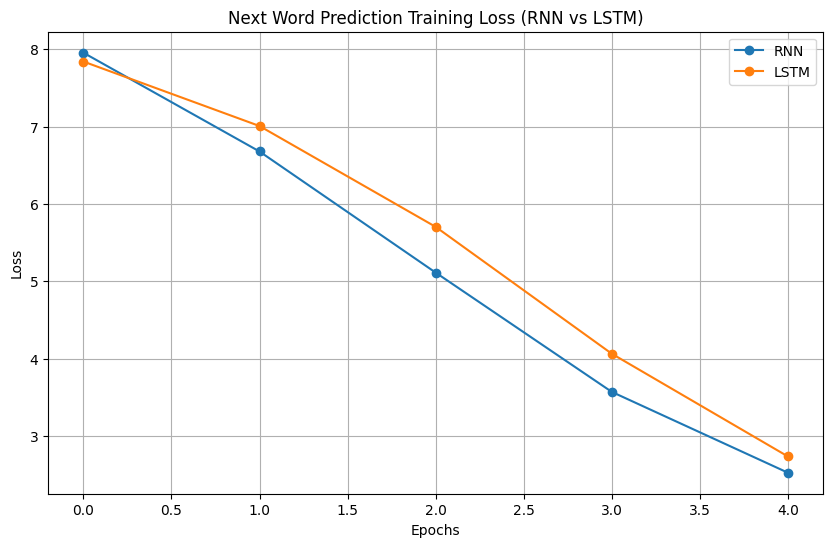

In [75]:
plot_losses(lm_loss_results, "Next Word Prediction Training Loss (RNN vs LSTM)")

## **2. Develop a sentence classification system using recurrent neural networks**

### a) Load a text classification dataset(IMDB Dataset.csv) and perform necessary preprocessing.
### b) Convert the text into numerical sequences using tokenization and padding.
### c) Construct and train a classification model using a Simple RNN architecture.
### d) Replace the Simple RNN with an LSTM and train the model.
### e) Compare the performance of RNN and LSTM models and justify which performs better. 

In [76]:
import pandas as pd

In [77]:
df = pd.read_csv('/home/142301026/Downloads/Deep_Learning/Lab5/data/IMDB Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [78]:
df['clean_tokens'] = df['review'].apply(preprocess_text)
df

,review,sentiment,clean_tokens
0,One of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,A wonderful little production. <br /><br />The...,positive,"[wonderful, little, production, br, br, filmin..."
2,I thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,"[basically, theres, family, little, boy, jake,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[petter, matteis, love, time, money, visually,..."
...,...,...,...
49995,I thought this movie did a down right good job...,positive,"[thought, movie, right, good, job, wasnt, crea..."
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,"[bad, plot, bad, dialogue, bad, acting, idioti..."
49997,I am a Catholic taught in parochial elementary...,negative,"[catholic, taught, parochial, elementary, scho..."
49998,I'm going to have to disagree with the previou...,negative,"[im, going, disagree, previous, comment, side,..."


In [79]:
word_counts = Counter(word for tokens in df['clean_tokens'] for word in tokens)
vocab = {word:i+2 for i,(word,count) in enumerate(word_counts.items())}
vocab_size_cls = len(vocab)+2

In [80]:
def text_to_seq(tokens):
    return [vocab.get(word,1) for word in tokens]

df['sequences'] = df['clean_tokens'].apply(text_to_seq)

In [119]:
class ClassificationDataset(Dataset):
    def __init__(self,sequences, labels):
        self.sequences = [torch.tensor(seq) for seq in sequences]
        self.labels = labels.values

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self,idx):
        return self.sequences[idx], torch.tensor(self.labels[idx], dtype=torch.float32)

def collate_fn_pad(batch):
    sequences, labels = zip(*batch)
    sequences_padded = pad_sequence(sequences, batch_first = True, padding_value = 0)
    labels = torch.stack(labels)
    return sequences_padded, labels

train_data, test_data, train_labels, test_labels = train_test_split(df['sequences'], df['sentiment'], test_size=0.2, random_state = 42)

In [120]:
train_dataset = ClassificationDataset(train_data,train_labels)
train_loader = DataLoader(train_dataset, batch_size=32, collate_fn=collate_fn_pad, shuffle = True)

In [121]:
train_loader

In [122]:
class TextClassificationModel(nn.Module):
    def __init__(self,rnn_type,vocab_size, embed_dim, hidden_dim, output_dim):
        super(TextClassificationModel,self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        if rnn_type == 'RNN':
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first = True)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first = True)
        self.fc = nn.Linear(hidden_dim,output_dim)

    def forward(self,x):
        embedded = self.embedding(x)
        output,hidden=self.rnn(embedded)

        if isinstance(hidden,tuple):
            hidden=hidden[0]
        final_hidden = hidden[0]
        return self.fc(final_hidden)

In [123]:
embed_dim = 64
hidden_dim = 128
output_dim = 1
criterion_cls = nn.BCEWithLogitsLoss()

In [124]:
model_cls = {
    'RNN' : TextClassificationModel('RNN', vocab_size_cls, embed_dim,hidden_dim,output_dim),
    'LSTM' : TextClassificationModel('LSTM', vocab_size_cls, embed_dim,hidden_dim,output_dim)
}

In [125]:
cls_loss_results = {}

for name, model in model_cls.items():
    print("Training {name} for Text Classification")
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    cls_loss_results[name] = train_and_evaluate(model, train_loader, criterion_cls, optimizer, epochs=5)

plot_losses(cls_loss_results, "Text Classification Training Loss (RNN vs LSTM)")

Training {name} for Text Classification


TypeError: new(): invalid data type 'str'

## 3. **Tuning the model**
### a) Modify the LSTM model by changing the embedding dimension and hidden layer size.
### b) Train the modified model using the same dataset.
### c) Record and compare the training accuracy of the original and modified models
### d) State which hyperparameter setting gives better performance and justify your answer

In [117]:
new_embed_dim = 128
new_hidden_dim = 256

In [118]:
model_cls_mod = {
    'LSTM' : TextClassificationModel('LSTM', vocab_size_cls, new_embed_dim,new_hidden_dim,output_dim)
}

In [93]:
cls_loss_results = {}

for name, model in model_cls.items():
    print(f"Training {name} for Text Classification")
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    cls_loss_results[name] = train_and_evaluate(model, train_loader, criterion_cls, optimizer, epochs=5)

plot_losses(cls_loss_results, "Text Classification Training Loss (RNN vs LSTM)")

Training RNN for Text Classification


TypeError: new(): invalid data type 'str'